# NFL TV Ratings - Ridge Regression with Lasso Feature Selection

This notebook is the last in a series of experiements where different modeling paradigms were trained on a shared dataset. Here we show that a well-engineered linear model can perform on-par with well-engineered gradient-boosted trees and neural networks on structured tabular data. This notebook demonstrates that on NFL Sunday TV ratings.

The pipeline: polynomial feature engineering on timeseries market/team features --> two-stage Lasso selection --> iterative bias-variance analysis --> curated feature set --> Ridge regression with time-series cross-validation.

## Baseline Comparison

| Model | Val R² | Notes |
|---|---|---|
| **Ridge Regression (this notebook)** | 91.3% shown below | Polynomial + Lasso selection + OHE market/team interactions |
| LightGBM + Optuna Hyperparam optimization | 91.5% | Native categoricals, 550-trial HPO |
| OHE MLP | 91.2% | [2022 -- 1024 -- 256 -- 64 -- 1]  (2,291,335 MLP params)|
| Embedding MLP | 90.9% | [245 -- 128 -- 64 -- 1]  (39,809 MLP params) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Lasso, Ridge, lasso_path
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
# custom module imports
from tv_ratings_preprocessing import isdivision, build_concurrent_features, build_normalized_market_draw
from MLP_analysis import plot_actual_vs_predicted, plot_subset_r2
print("Modules loaded.")

Modules loaded.


In [3]:
# The table located at DATA_PATH is the final result of our SQL project also located in the repo
DATA_PATH  = r"C:/Users/ASR10/PyPr/nfl_python_local/111B/nfl_python/nfl_data_pipeline/NFLTV_ML_11_rebuilt.csv"
TARGET_COL = 'AA__000_'  # Household Average Audience x1000 (how many households watched the game)
SPLIT_DATE = '2024-08-01'  # used only for feature selection, final model training will be time series cross validated. 

## Section 2 - Data Loading & Feature Engineering

We filter to keep only Sunday games (`Day == 'Sun'`). We restrict to `Season > 2013` where all timeseries features are fully populated.

In [4]:
df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df[['window']] = df[['window']].fillna('empty')

df = df[df['Day'] == 'Sun'].copy()
df = df[df['timeofday'] != 'morning'].copy()        # rule out international games (a subset of prime-time games, they take place primarily on sunday morning)
df = df.sort_values('Date').reset_index(drop=True)

print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Seasons: {df.Season.min()} - {df.Season.max()}')
print(f'Date range: {df.Date.min().date()} to {df.Date.max().date()}')

Dataset: 57,229 rows x 2001 cols
Seasons: 2010 - 2024
Date range: 2010-09-12 to 2025-01-05


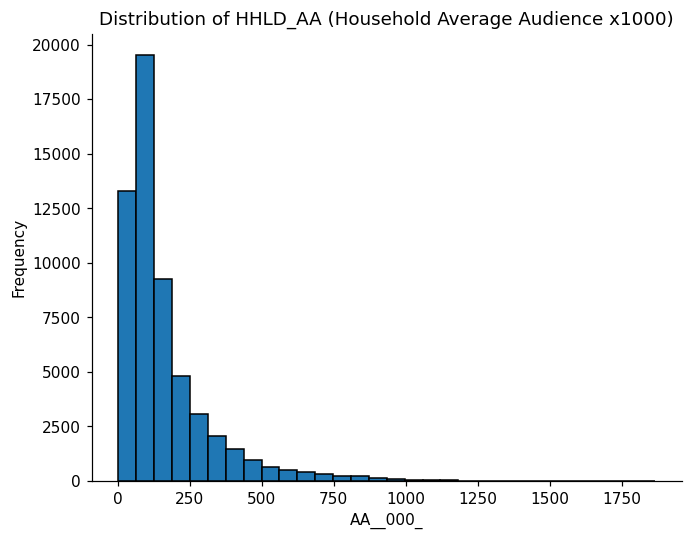

In [5]:
# View Target Distribution variable
df[TARGET_COL].plot(kind='hist', bins=30, edgecolor='black')
plt.xlabel(TARGET_COL)
plt.tight_layout()
plt.title("Distribution of HHLD_AA (Household Average Audience x1000)")
plt.show()


## Target Distribution Discussion

Because this target variable is heavily right-skewed (the mean is much larger than the median), there was careful consideration given to whether the target should be log-transformed. Log-transforming the target in these situations can protect against model bias. When training using Mean Absolute Error or R² as the scoring metric, large absolute or squared errors on high-viewership games can dominate the loss, and models can drift toward systemic overprediction of lower-viewed games as a result. Linear models are the most susceptible to this effect. Neural networks fit a nonlinear function and are nearly immune. Tree-based algorithms sit somewhere in between (a more detailed look at this can be found in `LightGBM_tv_ratings.ipynb`). Log-transforming the target shifts model bias toward the low end of the viewership curve, where the majority of games sit. This is a trade-off the practitioner has to weigh. When transforming, predictions must be exponentiated back to the original scale before reporting accuracy metrics, and a smearing correction should be applied at that step to unbias the final predictions.

The decision of whether to log-transform the target for linear model training was determined empirically. Two identical notebooks were constructed with the only difference being the scale of the training target. The cross-validated out-of-fold predictions on the raw target did not exhibit overprediction of low-viewership games, whereas models trained on only the training portion of the data did show some bias toward popular games. Training on the raw target also produced an additional 1.2% R². The conclusion was that we could achieve a more accurate model and avoid systematic out-of-sample bias by training on the raw target.

In [6]:
# ---- div_matchup ---------------------------------------------------------------
# If already upstream-computed, skip; otherwise derive via isdivision().
if 'div_matchup' not in df.columns:
    matchup_string = []
    ht_unique = df['ht'].unique().tolist()
    at_unique = df['at'].unique().tolist()
    all_teams = list(set(ht_unique + at_unique))
    for i in range(df.shape[0]):
        at_t = df['at'].iloc[i]
        ht_t = df['ht'].iloc[i]
        _, yn, _ = isdivision([at_t, ht_t])  # isdivision must be importable
        at_idx = all_teams.index(at_t)
        ht_idx = all_teams.index(ht_t)
        if at_idx < ht_idx:
            first_team, second_team = at_t, ht_t
        else:
            first_team, second_team = ht_t, at_t
        matchup_string.append(f'{first_team}_{second_team}' if yn == 1 else 'Other')
    insert_pos = df.columns.get_loc('ht') + 1
    df.insert(insert_pos, 'div_matchup', matchup_string)
    print(f'div_matchup computed. Division matchups: {(df.div_matchup != "Other").sum():,}')
else:
    print('div_matchup already in dataset.')
print(df['div_matchup'].value_counts().head(8))

div_matchup already in dataset.
div_matchup
Other          37333
COWBY_EAGLE     1184
COWBY_GIANT     1181
PCKRS_VIKNG      894
RAVEN_STLRS      868
BEARS_PCKRS      755
CMNDR_COWBY      749
BRNCO_CHIEF      703
Name: count, dtype: int64


In [7]:
# build_concurrent_features is imported from the shared module, it captures the strength of viewership draw of matchups occuring concurrently.
df = build_concurrent_features(df)

In [8]:
# built_normalized_market_draw is imported from the shared module, captures home/away team's prior-year market avg normalized by that market's average draw
df = build_normalized_market_draw(df, TARGET_COL)

normalized_ht_market_draw:
count    42548.000000
mean         0.992272
std          0.367951
min          0.069906
25%          0.773809
50%          0.961828
75%          1.136732
max          2.833352
Name: normalized_ht_market_draw, dtype: float64
NaN count: 14681 (expected for Season 1 and pre-2014 rows)


In [9]:
df = df[df['Season'] > 2013].copy()
df = df.sort_values('Date').reset_index(drop=True)
print(f'After Season > 2013 filter: {df.shape[0]:,} rows')
print(f'Seasons: {df.Season.min()} - {df.Season.max()}')

After Season > 2013 filter: 42,548 rows
Seasons: 2014 - 2024


## Section 3 - Feature Matrix Construction

**Numerical (43):** 38 existing timeseries/team-quality features (including `Season`) + 3 concurrent + 2 normalized draw. Degree-2 polynomial expansion yields ~989 terms. StandardScaler fitted on training data only.

**Boolean (5):** `brady`, `rodgers`, `mahomes`, `playoff_rematch`, `above_19_flag`. Passthrough as 0/1. (quarterback features measure the ratings effect that a star player has that is seperate from their team, and in the case of brady and rodgers, both qbs changed teams during our training window. Mahomes became a full-time starter in 2018, also during our training window)

**Categorical (5, OHE):** `week`, `timeofday`, `window`, `Affiliation`, `div_matchup`. OneHotEncoder fitted on training data only.

**Passthrough dummies:** All `Market_Team` and `Market_slot` binary columns. These model team-market and primary/secondary interactions directly and always enter the final model, bypassing Lasso feature selection by design.

In [10]:

# Train Test Split
train_mask = df['Date'] < SPLIT_DATE
test_mask  = ~train_mask

train = df[train_mask].copy()
test  = df[test_mask].copy()

y_train_raw = train[TARGET_COL].values
y_test_raw  = test[TARGET_COL].values
y_train     = y_train_raw.copy()
y_test      = y_test_raw.copy()

print(f'Train: {len(train):,} rows | Test: {len(test):,} rows')
print(f'y_train range: {y_train.min():.0f} - {y_train.max():.0f}')


Train: 38,443 rows | Test: 4,105 rows
y_train range: 3 - 1685


In [11]:
r'''
Raw target training: the model predicts ratings directly on the original scale.
This avoids the implicit bias toward low-rated games that log1p introduces.
MSE penalizes large absolute errors equally, so high-rating games receive more weight during training.
'''

'\nRaw target training: the model predicts ratings directly on the original scale.\nThis avoids the implicit bias toward low-rated games that log1p introduces.\nMSE penalizes large absolute errors equally, so high-rating games receive more weight during training.\n'

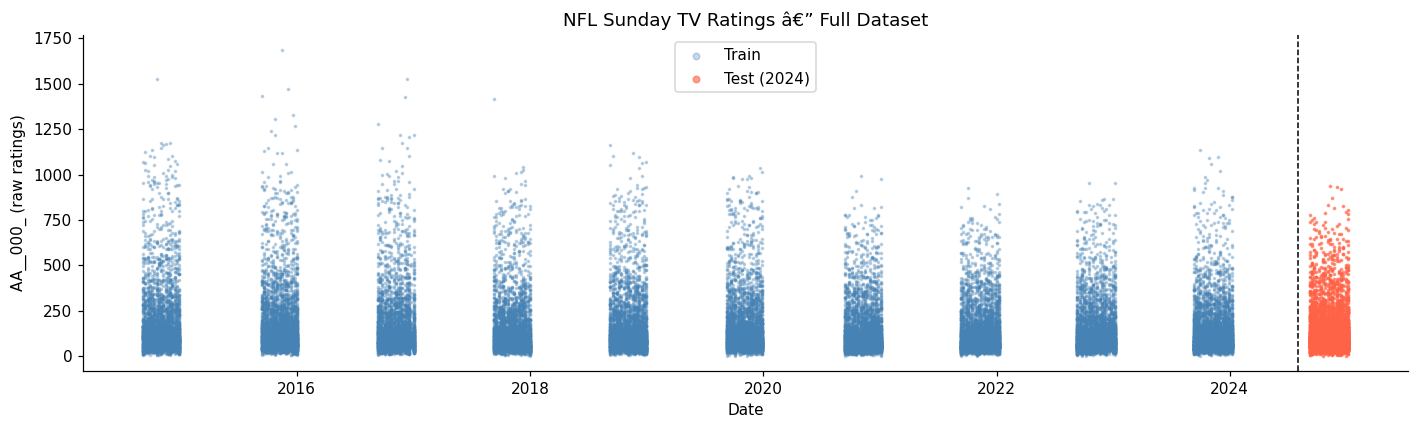

In [ ]:
# Train / Test visualization (numerical feature selection only, final training will be cross-validated)

fig, ax = plt.subplots(figsize=(13, 4))
ax.scatter(train['Date'], y_train_raw, s=2, color='steelblue', alpha=0.3, label='Train')
ax.scatter(test['Date'],  y_test_raw,  s=2, color='tomato',    alpha=0.6, label='Test (2024)')
ax.axvline(pd.Timestamp(SPLIT_DATE), color='black', ls='--', linewidth=1)
ax.set_xlabel('Date')
ax.set_ylabel('AA__000_ (raw ratings)')
ax.set_title('NFL Sunday TV Ratings . Full Dataset')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

In [13]:
predictors_numerical = [
    'prev_market_at_year_avg', 
    'prev_market_ht_year_avg',
    'prev_year_at_market_trend_todate', 
    'prev_year_ht_market_trend_todate',
    'prev_year_at_market_trend_4', 
    'prev_year_ht_market_trend_4',
    'prev_year_market_tod_avg', 
    'prev_market_tod_trend_todate', 
    'prev_market_tod_trend_4',
    'ht_market_todate_prediction', 
    'ht_market_4_prediction',
    'at_market_todate_prediction', 
    'at_market_4_prediction',
    'market_tod_todate_prediction', 
    'market_tod_4_prediction',
    'ht_expected_wins', 
    'at_expected_wins', 
    'sum_expected_wins',
    'sumwins_m_difwins', 
    'sumwins_m_difwins_d_week',
    'ht_playoff_make_prob', 
    'ht_playoff_miss_prob',
    'at_playoff_make_prob', 
    'at_playoff_miss_prob',
    'ht_division_prob', 
    'at_division_prob',
    'ht_conference_prob', 
    'at_conference_prob',
    'ht_superbowl_prob', 
    'at_superbowl_prob',
    'diff_playoff_make_prob', 
    'diff_playoff_miss_prob',
    'diff_wins', 
    'sumwins2_diffwins2',
    'diff_division_prob', 
    'diff_conference_prob', 
    'diff_superbowl_prob',
    'Season',
    # New: concurrent competition features
    'concurrent_count', 'total_concurrent_popularity', 'average_concurrent_popularity',
    # New: normalized market draw
    'normalized_ht_market_draw', 'normalized_at_market_draw',
]

predictors_bool    = ['playoff_rematch', 'brady', 'rodgers', 'mahomes', 'above_19_flag']  # 0/1, passthrough, no pre-processing needed
predictors_nominal = ['week', 'timeofday', 'window', 'Affiliation', 'div_matchup']        # categorical, will be one-hot encoded

columns = df.columns.values.tolist()
predictors_passthrough = columns[columns.index('Albuqu_primary'):]  # all features from Albuqu_primary onward are high-cardinality categorical features that will be passed through without pre-processing.

print(f'Numerical:   {len(predictors_numerical)}')
print(f'Boolean:     {len(predictors_bool)}')
print(f'Nominal:     {len(predictors_nominal)}')
print(f'Passthrough: {len(predictors_passthrough)}')

Numerical:   43
Boolean:     5
Nominal:     5
Passthrough: 1907


In [14]:
# Polynomial feature expansion

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_train_num_poly = poly.fit_transform(train[predictors_numerical].fillna(0))
X_test_num_poly  = poly.transform(test[predictors_numerical].fillna(0))
polynomial_column_names = poly.get_feature_names_out(predictors_numerical)
print(f'Polynomial terms: {len(polynomial_column_names):,}')

Polynomial terms: 989


In [15]:
# Numerical feature scaling

scaler = StandardScaler()
X_train_num_poly_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num_poly),
    columns=polynomial_column_names, index=train.index)  # fit_transform on train, transform on test to avoid data leakage

X_test_num_poly_scaled = pd.DataFrame(
    scaler.transform(X_test_num_poly),
    columns=polynomial_column_names, index=test.index)

In [16]:
# One-Hot-Encoding of categorical features

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(train[predictors_nominal])
ohe_feature_labels = ohe.get_feature_names_out(predictors_nominal)

ohe_df_train = pd.DataFrame(ohe.transform(train[predictors_nominal]),
                             columns=ohe_feature_labels, index=train.index)
ohe_df_test  = pd.DataFrame(ohe.transform(test[predictors_nominal]),
                             columns=ohe_feature_labels, index=test.index)
print(f'OHE columns: {len(ohe_feature_labels)}')

OHE columns: 82


In [17]:
# Assembling of training-ready dataframe

def assemble(split_df, poly_scaled, ohe_df):
    return pd.concat([poly_scaled, split_df[predictors_bool],
                      ohe_df, split_df[predictors_passthrough]], axis=1)

X_train_rdy = assemble(train, X_train_num_poly_scaled, ohe_df_train)
X_test_rdy  = assemble(test,  X_test_num_poly_scaled,  ohe_df_test)

print(f'X_train_rdy: {X_train_rdy.shape}')
print(f'X_test_rdy:  {X_test_rdy.shape}')
print(f'NaN in train: {X_train_rdy.isna().sum().sum()}')

X_train_rdy: (38443, 2983)
X_test_rdy:  (4105, 2983)
NaN in train: 0


## Section 4 - Feature Selection

Below we implement a multi-stage feature selection process anchored around L1 (Lasso) and L2 (Ridge) regularization. In the first stage, we use L1 regularization to push redundant or unhelpful feature coefficients to zero. We determine the alpha hyperparameter via a 5-fold cross validation grid gearch on the parameter, using the training dataset only. We speed up grid search by doing two passes: a course pass to find order of magnitude, followed by a fine search anchored by the best course parameter to further narrow down the optimal value. Optimal sparsity is determined based on the average accuracy the resulting model achieves when trained separately accross the 5 folds.

> Lasso operates only on the scaled polynomial numerical features. Passthrough and OHE features are always included by design because domain expertise suggests they will always be relevant. It is the polynomial numerial features that carry noise/redundancy and require pruning.

Non-zero coefficient features are then ranked by **mRMR (Minimum Redundancy Maximum Relevance)**. At each step, the algorithm selects the remaining feature that maximises `|corr(f, y)| − mean(|corr(f, s)| for s already selected)`. Unlike a plain correlation sort, mRMR penalises features that are collinear with what has already been chosen, so a feature that adds genuinely new information ranks higher than one that excedes it in target correlation but mostly duplicates an existing feature.

We then shift focus to an iterative, supervised, Ridge-regression, bias-variance tradeoff analysis. We loop through the mRMR list, adding one additional feature each pass, find the optimal L2 hyperparameter for the feature subset, and track train, test, and cv R squared scores as each additional feature is added. This allows the practitioner to see where features pragmatically add value, where train and test accuracy begin to diverge (overfitting), or where additional features no longer add significant value. In this step we also take the liberty to change the order of the mRMR list after visualization. This is a supervised approach that allows us to pick the smallest, most effective model possible. 

> This is where the test dataset comes into play. The final feature set is determined by the bias-variance elbow of both test and cv accuracy scores relative to the train curve

In [18]:
X_train_num_poly_scaled.shape

(38443, 989)

In [ ]:
# Course Lasso

lasso_coarse_grid = {'alpha': [0.001, 0.0025,  0.005, 0.0075, 0.01, .025, 0.05, .075, 0.1, 0.25, 0.5, 1]}
gs_lasso_1 = GridSearchCV(Lasso(max_iter=10000), lasso_coarse_grid,
                          cv=4, scoring='r2', n_jobs=1, verbose=0)

gs_lasso_1.fit(X_train_num_poly_scaled, y_train)
best_alpha_coarse = gs_lasso_1.best_params_['alpha']
print(f'Stage 1 best alpha: {best_alpha_coarse}  (CV R2: {gs_lasso_1.best_score_:.4f})')

Stage 1 best alpha: 0.25  (CV R2: 0.7364)


In [ ]:
# Fine Lasso

lo = best_alpha_coarse / 4
hi = best_alpha_coarse * 4
fine_alphas = sorted(np.round(np.logspace(np.log10(lo), np.log10(hi), 25), 6).tolist())
gs_lasso_2 = GridSearchCV(Lasso(max_iter=10000), {'alpha': fine_alphas},
                          cv=4, scoring='r2', n_jobs=1, verbose=0)
gs_lasso_2.fit(X_train_num_poly_scaled, y_train)
best_alpha_lasso = gs_lasso_2.best_params_['alpha']
print(f'Stage 2 best alpha: {best_alpha_lasso}  (CV R2: {gs_lasso_2.best_score_:.4f})')

Stage 2 best alpha: 0.140308  (CV R2: 0.7387)


In [21]:
lasso_final = Lasso(alpha=best_alpha_lasso, max_iter=50000)
lasso_final.fit(X_train_num_poly_scaled, y_train)

nonzero_idx = np.nonzero(lasso_final.coef_)[0]
features = [polynomial_column_names[i] for i in nonzero_idx]
print(f'Lasso retained {len(features)} of {len(polynomial_column_names):,} polynomial features')

Lasso retained 211 of 989 polynomial features


In [22]:
# ---- mRMR feature ranking ------------------------------------------------
# Minimum Redundancy Maximum Relevance: at each step, pick the feature that
# maximizes  |corr(f, y)| − mean(|corr(f, s)| for s already selected).
# Pure correlation ranking ignores that two high-corr features may be nearly
# identical. mRMR penalises redundancy with the already-selected set, so the
# ordering better reflects independent information gain.

Xtrain_sel = X_train_num_poly_scaled[features].copy()

# Precompute once: absolute feature/feature corr matrix and corr with target
feat_corr_abs = Xtrain_sel.corr().abs()
target_corr_signed = (Xtrain_sel.assign(__target__=y_train)
                                .corr()['__target__']
                                .drop('__target__'))
target_corr_abs = target_corr_signed.abs()

remaining = list(features)
selected  = []
# corr = []

while remaining:
    if not selected:
        best = max(remaining, key=lambda f: target_corr_abs[f])
    else:
        best = max(remaining, key=lambda f: target_corr_abs[f] - feat_corr_abs.loc[f, selected].mean())
        
    selected.append(best)
    remaining.remove(best)

ordered_features = selected

print('Top 15 features by mRMR ranking:')
for i, f in enumerate(ordered_features[:15], 1):
    s_idx = selected.index(f)
    red   = feat_corr_abs.loc[f, selected[:s_idx]].mean() if s_idx > 0 else 0.0
    score = target_corr_abs[f] - red
    print(f'  {i:2d}.  corr={target_corr_signed[f]:+.3f}  red={red:.3f}  mRMR={score:+.3f}  {f}')

Top 15 features by mRMR ranking:
   1.  corr=+0.788  red=0.000  mRMR=+0.788  prev_year_market_tod_avg normalized_at_market_draw
   2.  corr=+0.336  red=0.067  mRMR=+0.268  normalized_ht_market_draw^2
   3.  corr=+0.689  red=0.390  mRMR=+0.299  prev_year_market_tod_avg sumwins2_diffwins2
   4.  corr=+0.614  red=0.386  mRMR=+0.229  at_market_todate_prediction normalized_at_market_draw
   5.  corr=+0.721  red=0.488  mRMR=+0.233  prev_market_ht_year_avg^2
   6.  corr=+0.770  red=0.597  mRMR=+0.173  prev_market_at_year_avg at_expected_wins
   7.  corr=+0.649  red=0.503  mRMR=+0.146  ht_market_todate_prediction ht_market_4_prediction
   8.  corr=+0.683  red=0.543  mRMR=+0.140  prev_market_at_year_avg normalized_at_market_draw
   9.  corr=+0.784  red=0.630  mRMR=+0.154  prev_year_market_tod_avg normalized_ht_market_draw
  10.  corr=+0.756  red=0.645  mRMR=+0.111  prev_market_at_year_avg sumwins2_diffwins2
  11.  corr=+0.619  red=0.506  mRMR=+0.113  ht_market_todate_prediction normalized_ht_ma

In [23]:
corr_features = pd.DataFrame(data=target_corr_abs).index.values.tolist()

In [24]:
ordered_features_original = [
 'prev_year_market_tod_avg normalized_at_market_draw',
 'normalized_ht_market_draw^2',
 'prev_year_market_tod_avg sumwins2_diffwins2',
 'at_market_todate_prediction normalized_at_market_draw',
 'prev_market_ht_year_avg^2',
 'market_tod_4_prediction at_conference_prob',
 'at_market_todate_prediction average_concurrent_popularity',
 'prev_year_at_market_trend_todate market_tod_4_prediction',
 'market_tod_4_prediction ht_conference_prob',
 'prev_market_tod_trend_todate normalized_ht_market_draw',
 'ht_market_todate_prediction ht_market_4_prediction',
 'prev_market_at_year_avg normalized_at_market_draw',
 'prev_year_market_tod_avg normalized_ht_market_draw',
 'prev_market_at_year_avg sumwins2_diffwins2',
 'ht_market_todate_prediction normalized_ht_market_draw',
 'prev_market_at_year_avg^2',
 'prev_market_ht_year_avg ht_division_prob',
 'prev_market_at_year_avg at_division_prob',
 'market_tod_todate_prediction ht_playoff_miss_prob',
 'prev_year_ht_market_trend_todate market_tod_4_prediction',
 'prev_market_tod_trend_4^2',
 'ht_market_todate_prediction normalized_at_market_draw',
 'prev_market_ht_year_avg diff_wins',
 'normalized_ht_market_draw normalized_at_market_draw',
 'at_market_todate_prediction market_tod_todate_prediction',
 'prev_year_market_tod_avg ht_market_4_prediction',
 'prev_market_at_year_avg sumwins_m_difwins_d_week',
 'prev_market_ht_year_avg at_market_4_prediction',
 'market_tod_todate_prediction normalized_at_market_draw',
 'prev_year_ht_market_trend_todate^2',
 'sumwins2_diffwins2 concurrent_count',
 'prev_market_ht_year_avg market_tod_4_prediction',
 'sumwins_m_difwins normalized_at_market_draw',
 'sumwins_m_difwins normalized_ht_market_draw',
 'prev_market_at_year_avg ht_market_4_prediction',
 'prev_market_at_year_avg diff_wins',
 'ht_market_todate_prediction ht_division_prob',
 'prev_year_market_tod_avg average_concurrent_popularity',
 'prev_market_at_year_avg at_expected_wins',
 'prev_market_at_year_avg at_conference_prob',
 'at_market_todate_prediction normalized_ht_market_draw',
 'market_tod_4_prediction ht_superbowl_prob',
 'prev_year_at_market_trend_todate^2',
 'ht_market_4_prediction diff_wins',
 'prev_market_tod_trend_todate prev_market_tod_trend_4',
 'market_tod_4_prediction sumwins_m_difwins_d_week',
 'prev_market_ht_year_avg prev_year_at_market_trend_todate',
 'prev_market_at_year_avg ht_playoff_miss_prob',
 'ht_market_4_prediction normalized_ht_market_draw',
 'prev_year_market_tod_avg ht_playoff_miss_prob',
 'ht_market_todate_prediction ht_playoff_make_prob',
 'normalized_at_market_draw^2',
 'ht_market_4_prediction^2',
 'prev_market_ht_year_avg at_conference_prob',
 'at_market_todate_prediction^2',
 'prev_market_ht_year_avg sumwins_m_difwins_d_week',
 'at_market_4_prediction normalized_ht_market_draw',
 'market_tod_4_prediction normalized_ht_market_draw',
 'ht_market_4_prediction normalized_at_market_draw',
 'market_tod_todate_prediction normalized_ht_market_draw',
 'prev_market_at_year_avg market_tod_todate_prediction',
 'Season normalized_ht_market_draw',
 'ht_market_todate_prediction market_tod_todate_prediction',
 'ht_expected_wins normalized_at_market_draw',
 'prev_market_ht_year_avg market_tod_todate_prediction',
 'at_market_todate_prediction at_playoff_miss_prob',
 'market_tod_4_prediction sumwins2_diffwins2',
 'at_expected_wins normalized_ht_market_draw',
 'prev_year_market_tod_avg diff_wins',
 'market_tod_todate_prediction sumwins2_diffwins2',
 'prev_market_tod_trend_todate normalized_at_market_draw',
 'ht_market_todate_prediction ht_playoff_miss_prob',
 'ht_market_todate_prediction ht_superbowl_prob',
 'market_tod_todate_prediction^2',
 'prev_market_tod_trend_todate^2',
 'prev_year_market_tod_avg total_concurrent_popularity',
 'prev_year_market_tod_avg^2',
 'at_market_4_prediction normalized_at_market_draw',
 'ht_market_todate_prediction^2',
 'prev_market_ht_year_avg average_concurrent_popularity',
 'prev_market_tod_trend_todate ht_market_todate_prediction',
 'prev_market_ht_year_avg prev_year_ht_market_trend_todate',
 'prev_year_ht_market_trend_todate prev_year_ht_market_trend_4',
 'prev_market_tod_trend_4 at_market_4_prediction',
 'prev_year_at_market_trend_todate prev_year_at_market_trend_4',
 'prev_market_tod_trend_todate at_conference_prob',
 'market_tod_todate_prediction average_concurrent_popularity',
 'Season^2',
 'prev_year_at_market_trend_todate prev_market_tod_trend_4',
 'average_concurrent_popularity normalized_at_market_draw',
 'prev_market_tod_trend_todate market_tod_todate_prediction',
 'prev_year_ht_market_trend_4^2',
 'market_tod_4_prediction diff_wins',
 'prev_market_at_year_avg prev_year_at_market_trend_todate',
 'market_tod_4_prediction average_concurrent_popularity',
 'prev_year_ht_market_trend_todate prev_year_at_market_trend_4',
 'prev_market_at_year_avg prev_year_ht_market_trend_todate',
 'prev_year_at_market_trend_4^2',
 'Season'
 ]


## Section 5 - Bias-Variance Analysis

For k = 1 to len(ordered_features), we fit a Ridge model on the top-k Lasso-selected polynomial features and record train, test, and CV R² on the original scale. This reveals where adding features stops helping the test set and overfitting begins. The elbow in the test and CV R² curve informs the feature curation in Section 6.

> This feature selection process still only operates on the polynomial numerical features. We want to squeeze all the generalizable signal out of them that we can before then adding back in the boolean, OHE, and passthrough features for final training and validation testing. 

In [25]:
alpha_ridge_grid = [.01, .05, .1, .5, 1, 10, 50, 100, 200, 400, 750]

STEP = 1

train_r2_curve, test_r2_curve = [], []

for k in range(1, len(ordered_features_original) + 1, STEP):
    chosen = ordered_features_original[:k]
    # X_tr = pd.concat([X_train_num_poly_scaled[chosen], train[predictors_bool],
    #                   ohe_df_train, train[predictors_passthrough]], axis=1)
    # X_te = pd.concat([X_test_num_poly_scaled[chosen], test[predictors_bool],
    #                   ohe_df_test, test[predictors_passthrough]], axis=1)

    X_tr = X_train_num_poly_scaled[chosen]
    X_te = X_test_num_poly_scaled[chosen]


    gs = GridSearchCV(Ridge(max_iter=20000), {'alpha': alpha_ridge_grid},
                      cv=3, scoring='neg_mean_squared_error', n_jobs=1)
    gs.fit(X_tr, y_train)
    m = Ridge(alpha=gs.best_params_['alpha'], max_iter=20000).fit(X_tr, y_train)

    tr_r2 = r2_score(y_train, m.predict(X_tr))
    te_r2 = r2_score(y_test,  m.predict(X_te))
    train_r2_curve.append(tr_r2)
    test_r2_curve.append(te_r2)
    print(f'k={k:2d}  train={tr_r2:.4f}  test={te_r2:.4f}  alpha={gs.best_params_["alpha"]}, feat={ordered_features_original[k-1]}')

k= 1  train=0.6203  test=0.5607  alpha=100, feat=prev_year_market_tod_avg normalized_at_market_draw
k= 2  train=0.7004  test=0.6591  alpha=100, feat=normalized_ht_market_draw^2
k= 3  train=0.7261  test=0.6602  alpha=100, feat=prev_year_market_tod_avg sumwins2_diffwins2
k= 4  train=0.7412  test=0.6906  alpha=750, feat=at_market_todate_prediction normalized_at_market_draw
k= 5  train=0.7717  test=0.7332  alpha=750, feat=prev_market_ht_year_avg^2
k= 6  train=0.7717  test=0.7330  alpha=750, feat=market_tod_4_prediction at_conference_prob
k= 7  train=0.7747  test=0.7376  alpha=750, feat=at_market_todate_prediction average_concurrent_popularity
k= 8  train=0.7773  test=0.7387  alpha=750, feat=prev_year_at_market_trend_todate market_tod_4_prediction
k= 9  train=0.7776  test=0.7375  alpha=750, feat=market_tod_4_prediction ht_conference_prob
k=10  train=0.7778  test=0.7363  alpha=750, feat=prev_market_tod_trend_todate normalized_ht_market_draw
k=11  train=0.7812  test=0.7445  alpha=750, feat=ht

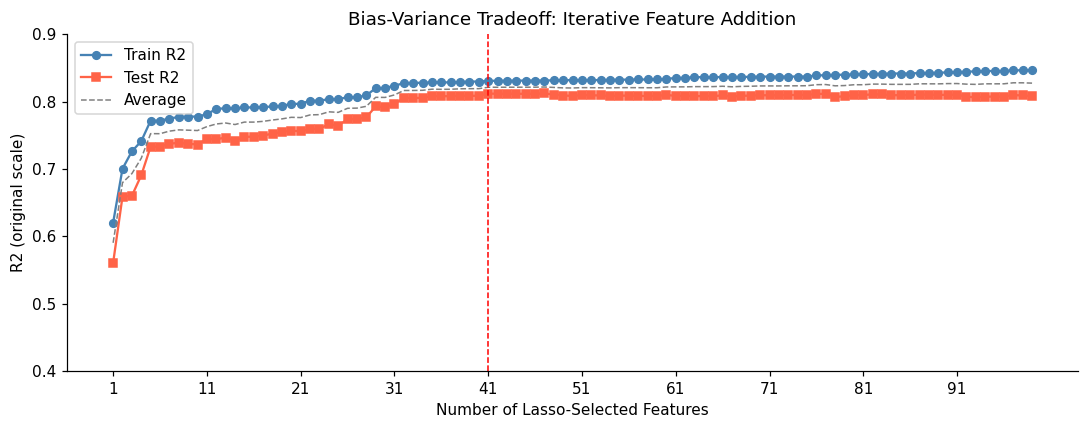

In [26]:
ks = list(range(1, len(ordered_features_original) + 1, STEP))
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ks, train_r2_curve, 'o-', color='steelblue', label='Train R2', markersize=5)
ax.plot(ks, test_r2_curve,  's-', color='tomato',    label='Test R2',  markersize=5)
ax.plot(ks, [(a+b)/2 for a, b in zip(train_r2_curve, test_r2_curve)],
        '--', color='gray', label='Average', linewidth=1)
ax.set_xlabel('Number of Lasso-Selected Features')
ax.set_ylabel('R2 (original scale)')
ax.set_title('Bias-Variance Tradeoff: Iterative Feature Addition')
ax.legend()
TICK_EVERY = 10
ax.set_xticks([k for k in ks if (k - ks[0]) % TICK_EVERY == 0])
ax.set_ylim(.4, .9)
plt.tight_layout()
plt.axvline(x=41, color='red', ls='--', linewidth=1, label='Best Test R2')
plt.show()

## Section 6 - Feature Curation

The bias-variance plot shows where test R squared peaks and begins to decline. Not every Lasso-selected feature improves out-of-sample performance. Some interaction terms are collinear or capture market-specific noise. After inspecting the plot, I manually curate the final feature set below.

In [27]:
# -------------- Curated feature list - update after inspecting the bias-variance plot above -----------------
ordered_features_curated = [
 'prev_year_market_tod_avg normalized_at_market_draw',
 'normalized_ht_market_draw^2',
 'prev_year_market_tod_avg sumwins2_diffwins2',
 'at_market_todate_prediction normalized_at_market_draw',
 'prev_market_ht_year_avg^2',
 'market_tod_4_prediction at_conference_prob',
 'at_market_todate_prediction average_concurrent_popularity',
 'prev_year_at_market_trend_todate market_tod_4_prediction',
 'market_tod_4_prediction ht_conference_prob',
 'prev_market_tod_trend_todate normalized_ht_market_draw',
 'ht_market_todate_prediction ht_market_4_prediction',
 'prev_market_at_year_avg normalized_at_market_draw',
 'prev_year_market_tod_avg normalized_ht_market_draw',
 'prev_market_at_year_avg sumwins2_diffwins2',
 'ht_market_todate_prediction normalized_ht_market_draw',
 'prev_market_at_year_avg^2',
 'prev_market_ht_year_avg ht_division_prob',
 'prev_market_at_year_avg at_division_prob',
 'market_tod_todate_prediction ht_playoff_miss_prob',
 'prev_year_ht_market_trend_todate market_tod_4_prediction',
 'prev_market_tod_trend_4^2',
 'ht_market_todate_prediction normalized_at_market_draw',
 'prev_market_ht_year_avg diff_wins',
 'normalized_ht_market_draw normalized_at_market_draw',
 'at_market_todate_prediction market_tod_todate_prediction',
 'prev_year_market_tod_avg ht_market_4_prediction',
 'prev_market_at_year_avg sumwins_m_difwins_d_week',
 'prev_market_ht_year_avg at_market_4_prediction',
 'market_tod_todate_prediction normalized_at_market_draw',
 'prev_year_ht_market_trend_todate^2',
 'sumwins2_diffwins2 concurrent_count',
 'prev_market_ht_year_avg market_tod_4_prediction',
 'sumwins_m_difwins normalized_at_market_draw',
 'sumwins_m_difwins normalized_ht_market_draw',
 'prev_market_at_year_avg ht_market_4_prediction',
 'prev_market_at_year_avg diff_wins',
 'ht_market_todate_prediction ht_division_prob',
 'prev_year_market_tod_avg average_concurrent_popularity',
 'prev_market_at_year_avg at_expected_wins',
 'prev_market_at_year_avg at_conference_prob',
 'at_market_todate_prediction normalized_ht_market_draw'
 ]


missing = [f for f in ordered_features_curated if f not in ordered_features_original]
if missing:
    print(f'WARNING: {len(missing)} curated features not found in Lasso output:')
    for f in missing:
        print(f'  {f}')
    print('Update ordered_features_curated based on the new Lasso output above.')
else:
    print(f'All {len(ordered_features_curated)} curated features confirmed in Lasso output.')

All 41 curated features confirmed in Lasso output.


## Section 7 - Time-Series CV & OOF Collection

Here the boolean, OHE, and passthrough features are added back into the model with the curated numerical feature set for final training and out-of-fold accuracy reporting. For cross validation we use four expanding-window, time-series folds, each with ~4,100 validation rows. Predictions on each validation fold are concatenated into an OOF (out-of-fold) array covering the full training period. All R squared metrics (overall and by subgroup) are computed from OOF predictions, not from the final model's in-sample predictions.

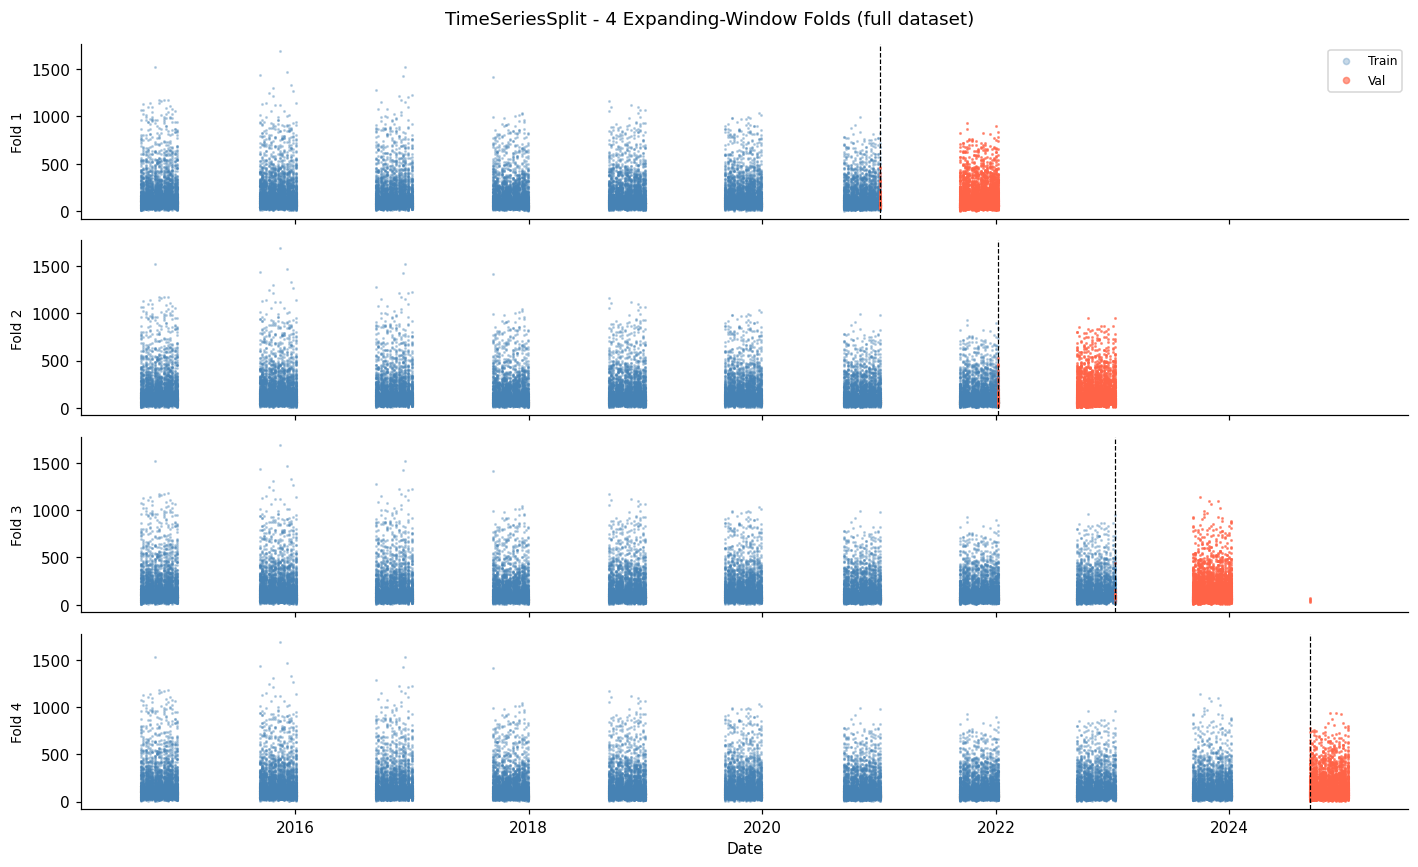

In [28]:
tscv = TimeSeriesSplit(n_splits=4, test_size=4100, gap=0)

fig, axes = plt.subplots(4, 1, figsize=(13, 8), sharex=True)
for fold, (tr_idx, val_idx) in enumerate(tscv.split(df)):
    ax = axes[fold]
    train_dates = df.iloc[tr_idx]["Date"]
    val_dates   = df.iloc[val_idx]["Date"]
    ax.scatter(train_dates, df[TARGET_COL].values[tr_idx],  s=1, color="steelblue", alpha=0.3, label="Train")
    ax.scatter(val_dates,   df[TARGET_COL].values[val_idx], s=1, color="tomato",    alpha=0.6, label="Val")
    ax.axvline(val_dates.min(), color="black", ls="--", linewidth=0.8)
    ax.set_ylabel(f"Fold {fold+1}", fontsize=9)
    if fold == 0:
        ax.legend(markerscale=4, fontsize=8)
axes[-1].set_xlabel("Date")
fig.suptitle("TimeSeriesSplit - 4 Expanding-Window Folds (full dataset)", fontsize=12)
plt.tight_layout()
plt.show()

## Section 8 - Ridge Hyperparameter Tuning

We select the Ridge regularization strength using GridSearchCV with `TimeSeriesSplit` as the inner CV strategy - the same temporal structure as the final evaluation. `best_alpha` flows into all downstream training and reporting

In [29]:
# Train curated matrix:  used for alpha tuning only (no test data leakage)
X_train_curated = pd.concat([
    X_train_num_poly_scaled[ordered_features_curated],
    train[predictors_bool],
    ohe_df_train,
    train[predictors_passthrough],
], axis=1)

# Full dataset curated matrix:  used for OOF loop and final model
X_all_poly_scaled = pd.DataFrame(
    scaler.transform(poly.transform(df[predictors_numerical].fillna(0))),
    columns=polynomial_column_names, index=df.index)

ohe_all = pd.DataFrame(ohe.transform(df[predictors_nominal]),
                        columns=ohe_feature_labels, index=df.index)

X_all_curated = pd.concat([
    X_all_poly_scaled[ordered_features_curated],
    df[predictors_bool],
    ohe_all,
    df[predictors_passthrough],
], axis=1)

y_all_raw = df[TARGET_COL].values

print(f"X_train_curated: {X_train_curated.shape}  (alpha tuning)")
print(f"X_all_curated:   {X_all_curated.shape}   (OOF + final model)")

X_train_curated: (38443, 2035)  (alpha tuning)
X_all_curated:   (42548, 2035)   (OOF + final model)


In [ ]:
# alpha_ridge_grid = [.001, .01, 1, 10, 100]
# [.001, .002, .003, .004, .005, .006, .007, .008, .009, .01]
# [.01, .02, .03, .04, .05, .06, .07, .08, .09, 1]
alpha_ridge_grid = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 30, 40, 50]


In [31]:
gs_alpha = GridSearchCV(
    Ridge(max_iter=20000),
    {'alpha': alpha_ridge_grid},
    cv=tscv, scoring='r2', n_jobs=1, verbose=0,
)
gs_alpha.fit(X_train_curated, y_train)
best_alpha = gs_alpha.best_params_['alpha']
print(f'best_alpha = {best_alpha}  (CV R2: {gs_alpha.best_score_:.4f})')

best_alpha = 5  (CV R2: 0.9072)


In [32]:
oof_preds = np.full(len(X_all_curated), np.nan)
fold_train_r2, fold_val_r2 = [], []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_all_curated)):
    X_fold_tr  = X_all_curated.iloc[tr_idx]
    X_fold_val = X_all_curated.iloc[val_idx]
    y_fold_tr  = y_all_raw[tr_idx]
    y_fold_val = y_all_raw[val_idx]

    m = Ridge(alpha=best_alpha, max_iter=100000).fit(X_fold_tr, y_fold_tr)

    oof_preds[val_idx] = m.predict(X_fold_val)

    tr_r2  = r2_score(y_fold_tr,  m.predict(X_fold_tr))
    val_r2 = r2_score(y_fold_val, oof_preds[val_idx])
    fold_train_r2.append(tr_r2)
    fold_val_r2.append(val_r2)
    print(f'Fold {fold+1}: train R2={tr_r2:.4f}  val R2={val_r2:.4f}')

print(f'Mean train R2: {np.mean(fold_train_r2):.4f}')
print(f'Mean val R2:   {np.mean(fold_val_r2):.4f}')


Fold 1: train R2=0.9394  val R2=0.9092
Fold 2: train R2=0.9382  val R2=0.9214
Fold 3: train R2=0.9382  val R2=0.9108
Fold 4: train R2=0.9373  val R2=0.9094
Mean train R2: 0.9383
Mean val R2:   0.9127


In [33]:
oof_mask = ~np.isnan(oof_preds)
oof_df = df.iloc[oof_mask].copy()[
    ["ht", "at", "Market_abrev", "Affiliation", "window", "Season"]
].reset_index(drop=True)
oof_df["y_true"] = y_all_raw[oof_mask]
oof_df["y_pred"] = oof_preds[oof_mask]

overall_oof_r2 = r2_score(oof_df["y_true"], oof_df["y_pred"])
print(f"OOF rows:        {len(oof_df):,}  (last 4 folds of full dataset)")
print(f"Overall OOF R2:  {overall_oof_r2:.4f}")

OOF rows:        16,400  (last 4 folds of full dataset)
Overall OOF R2:  0.9128


## Section 9: Final Model Training

Ridge trained on the full dataset (train + test) using `best_alpha`. The final model is used only for coefficient extraction and the team-market heatmap, not for R squared reporting.

In [34]:
oof_df.isna().sum()

ht              0
at              0
Market_abrev    0
Affiliation     0
window          0
Season          0
y_true          0
y_pred          0
dtype: int64

In [35]:
final_model = Ridge(alpha=best_alpha, max_iter=10000)
final_model.fit(X_all_curated, y_all_raw)

full_r2 = r2_score(y_all_raw, final_model.predict(X_all_curated))
print(f'Final model in-sample R2: {full_r2:.4f}')


Final model in-sample R2: 0.9357


## Section 10:  Model Evaluation

All metrics use OOF predictions from the 4-fold time-series CV run on the full dataset. The last fold's validation window covers the 2024 season, so those predictions come from a model that has never seen 2024 data. Subset R² groups the OOF rows and measures explained variance within each group.

In [ ]:
def plot_actual_vs_predicted(y_true, y_pred, title=''):
    # --- Actual vs Predicted (Validation Set) ------------------------------------
    val_r2 = r2_score(y_true, y_pred)
    val_rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

    print('=' * 50)
    print(f'  Val R²        : {val_r2:.4f}  (raw scale)')
    if np.all(y_pred > -1):
        val_r2_log = r2_score(np.log1p(y_true), np.log1p(y_pred))
        print(f'  Val R² (log)  : {val_r2_log:.4f}  (log1p scale)')
    else:
        n_neg = int(np.sum(y_pred <= -1))
        print(f'  Val R² (log)  : n/a  ({n_neg} predictions <= -1, log undefined)')
    print(f'  Val RMSE      : {val_rmse:.2f}')
    print('=' * 50)
    print()
    print('Baseline comparison:')
    print(f'  Ridge (Linear)    : ~0.913')
    print(f'  MLP (OHE)         : ~0.912')
    print(f'  LightGBM          : ~0.915')

    # --- scatter plot ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(y_true, y_pred, alpha=0.15, s=4, color='steelblue')
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    ax.set_xlabel('Actual Ratings')
    ax.set_ylabel('Predicted Ratings (Val)')
    ax.set_title(f'{title}  Val R²={val_r2:.4f}' if title else f'Actual vs Predicted — Val R²={val_r2:.4f}')
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    return fig

Overall OOF R2 (16,400 rows): 0.9128
  Val R²        : 0.9128  (raw scale)
  Val R² (log)  : n/a  (21 predictions <= -1, log undefined)
  Val RMSE      : 39.21

Baseline comparison:
  Ridge (Linear)    : ~0.909
  MLP (OHE)         : ~0.912
  LightGBM          : ~0.915


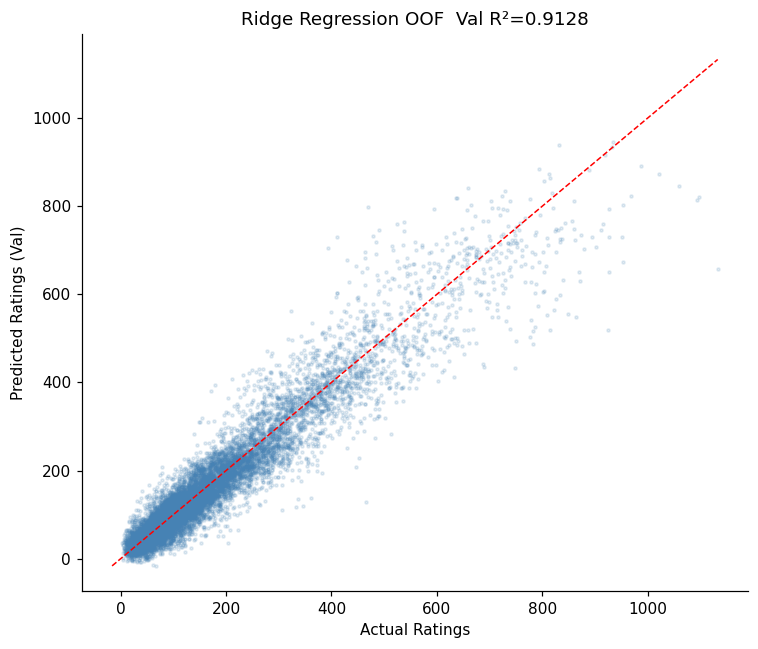

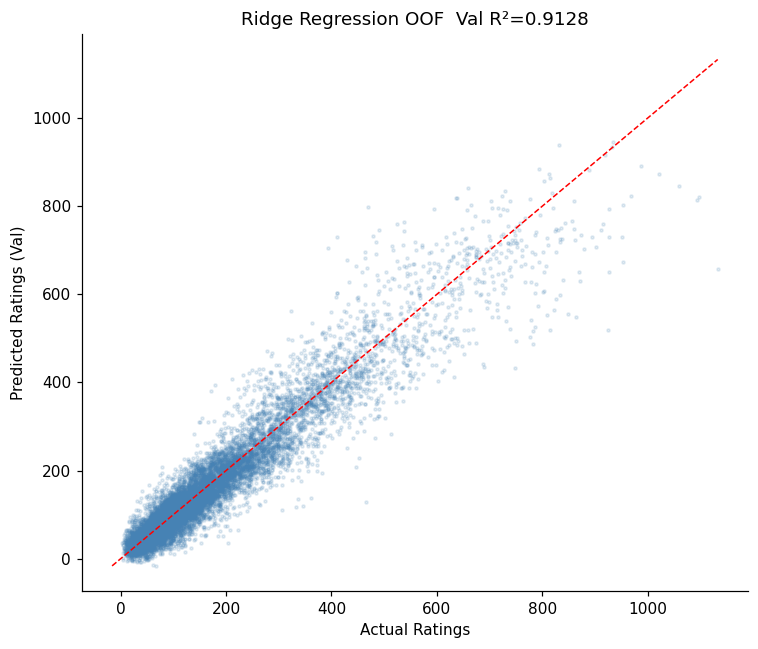

In [37]:
print(f"Overall OOF R2 ({len(oof_df):,} rows): {overall_oof_r2:.4f}")
plot_actual_vs_predicted(oof_df['y_true'].values, oof_df['y_pred'].values, title='Ridge Regression OOF')

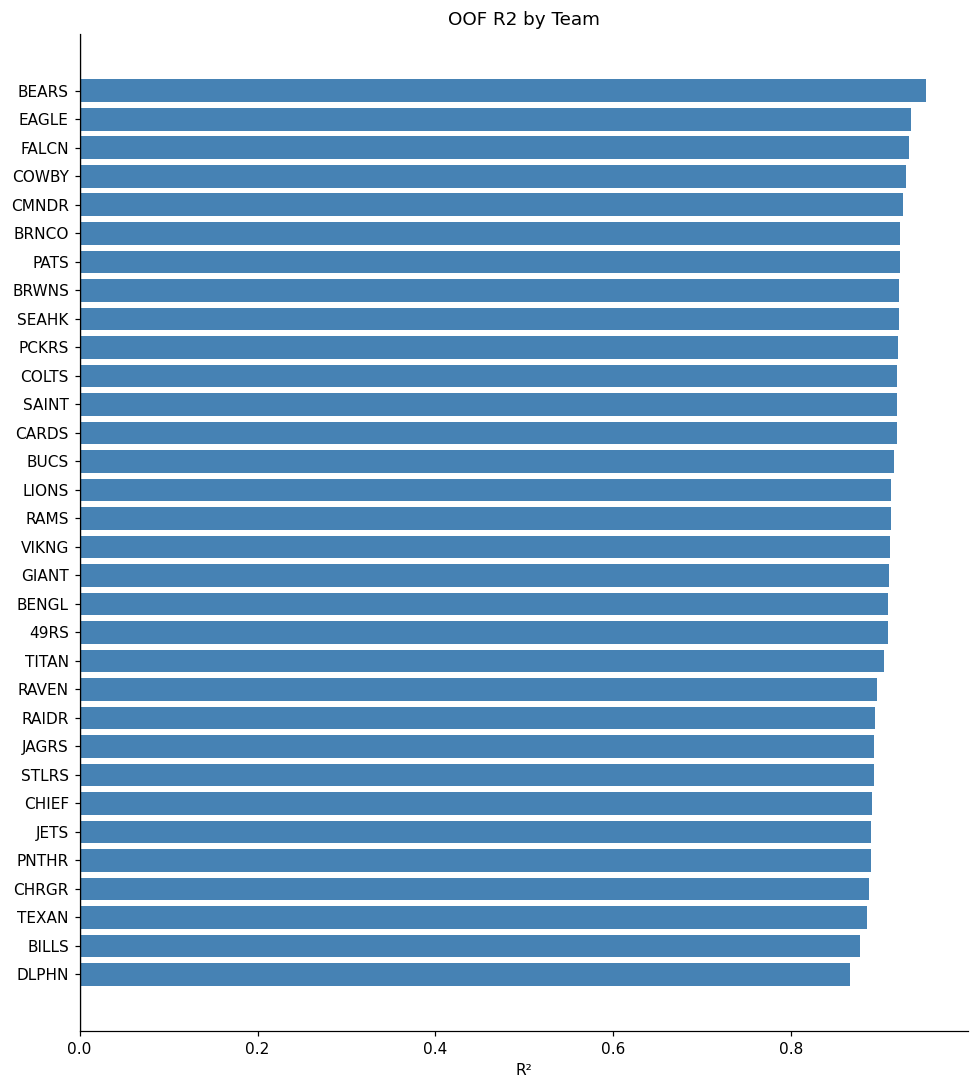

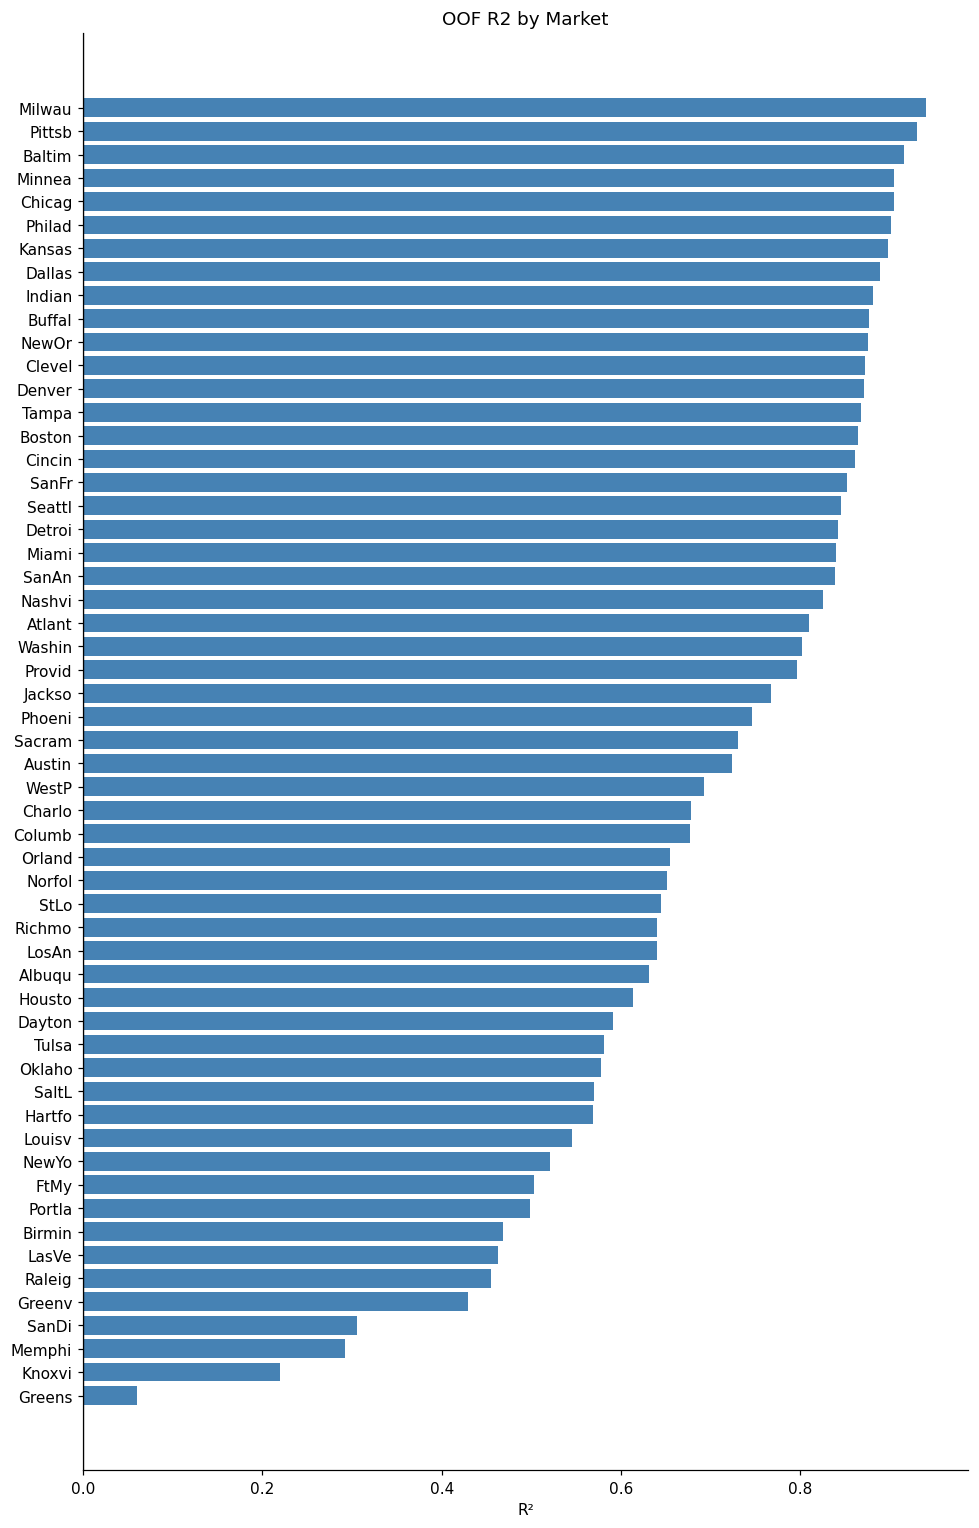

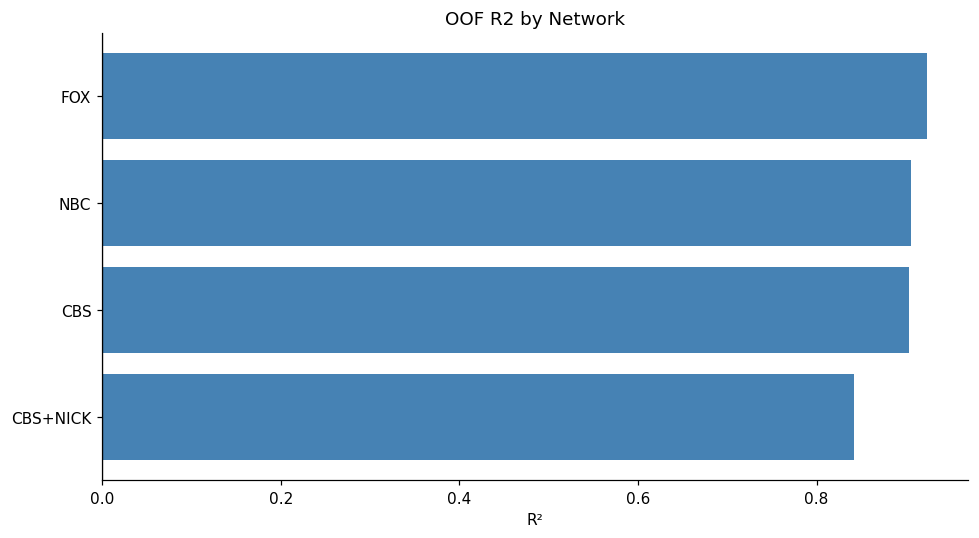

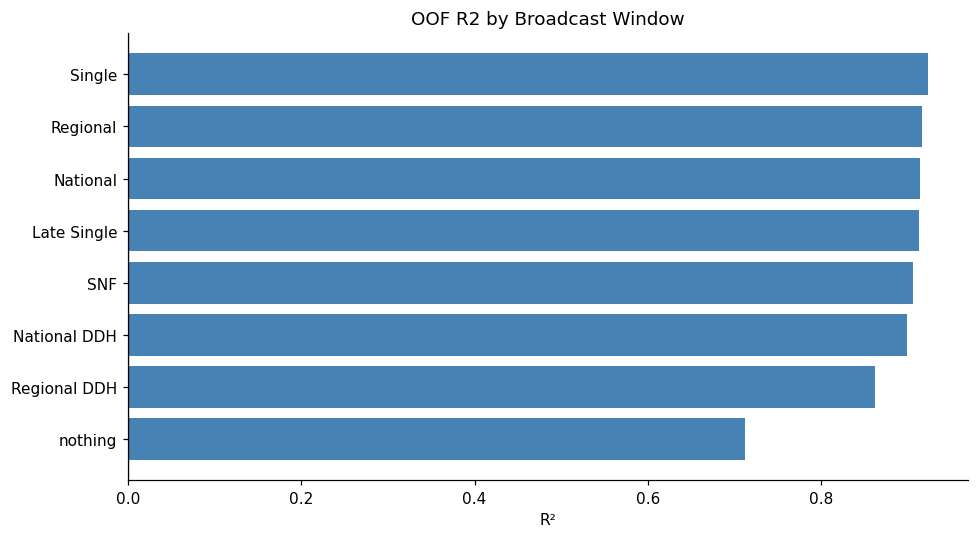

Rating tier accuracy (threshold = 150):
Tier                    n  mean_true  mean_pred     RMSE      MAE
--------------------------------------------------------------
< 150  (low)        11399       79.2       80.1    23.24    17.20
>= 150  (high)       5001      296.8      286.3    61.72    43.94


In [38]:
home_rows = oof_df[['ht', 'Market_abrev', 'y_true', 'y_pred']].rename(columns={'ht': 'team'})
away_rows = oof_df[['at', 'Market_abrev', 'y_true', 'y_pred']].rename(columns={'at': 'team'})
oof_team  = pd.concat([home_rows, away_rows]).reset_index(drop=True)

plot_subset_r2(oof_team['y_true'].values, oof_team['y_pred'].values, oof_team['team'].values,
               title='OOF R2 by Team', figsize=(9, 10))
plot_subset_r2(oof_df['y_true'].values, oof_df['y_pred'].values, oof_df['Market_abrev'].values,
               title='OOF R2 by Market', figsize=(9, 14))
plot_subset_r2(oof_df['y_true'].values, oof_df['y_pred'].values, oof_df['Affiliation'].values,
               title='OOF R2 by Network', figsize=(9, 5))
plot_subset_r2(oof_df['y_true'].values, oof_df['y_pred'].values, oof_df['window'].values,
               title='OOF R2 by Broadcast Window', figsize=(9, 5))

# ── Rating tier accuracy (< 150 vs >= 150) ─────────────────────────────────────
print('Rating tier accuracy (threshold = 150):')
print(f'{"Tier":<18} {"n":>6} {"mean_true":>10} {"mean_pred":>10} {"RMSE":>8} {"MAE":>8}')
print('-' * 62)
_yt = oof_df['y_true'].values
_yp = oof_df['y_pred'].values
for label, mask in [('< 150  (low)', _yt < 150), ('>= 150  (high)', _yt >= 150)]:
    yt = _yt[mask]
    yp = _yp[mask]
    rmse = np.sqrt(np.mean((yt - yp) ** 2))
    mae  = np.mean(np.abs(yt - yp))
    print(f'{label:<18} {mask.sum():>6} {yt.mean():>10.1f} {yp.mean():>10.1f} {rmse:>8.2f} {mae:>8.2f}')


## Section 11:  Model Interpretation

Unlike tree-based models, Ridge coefficients are directly interpretable. The team-market passthrough features give us a coefficient matrix  (the model's learned incremental rating effect for each team appearing in each market) holding all other features constant. Blue = team draws lower than market baseline in that market; red = above baseline.

In [39]:
final_features = X_all_curated.columns.tolist()
coefs = final_model.coef_

pass_start = final_features.index('Albuqu_primary')
markets = sorted(df['Market_abrev'].unique())
teams   = sorted(df['ht'].unique())
coeff_matrix = np.zeros((len(teams), len(markets)))

for i in range(pass_start, len(final_features)):
    fname = final_features[i]
    parts = fname.split('_', 1)
    if len(parts) != 2:
        continue
    mkt, team = parts[0], parts[1]
    if mkt in markets and team in teams:
        coeff_matrix[teams.index(team)][markets.index(mkt)] = coefs[i]

coef_df = pd.DataFrame(coeff_matrix, index=teams, columns=markets)
print(f'Coefficient matrix: {coef_df.shape}')
print(f'Non-zero entries: {(coef_df != 0).sum().sum()}')

Coefficient matrix: (32, 56)
Non-zero entries: 1792


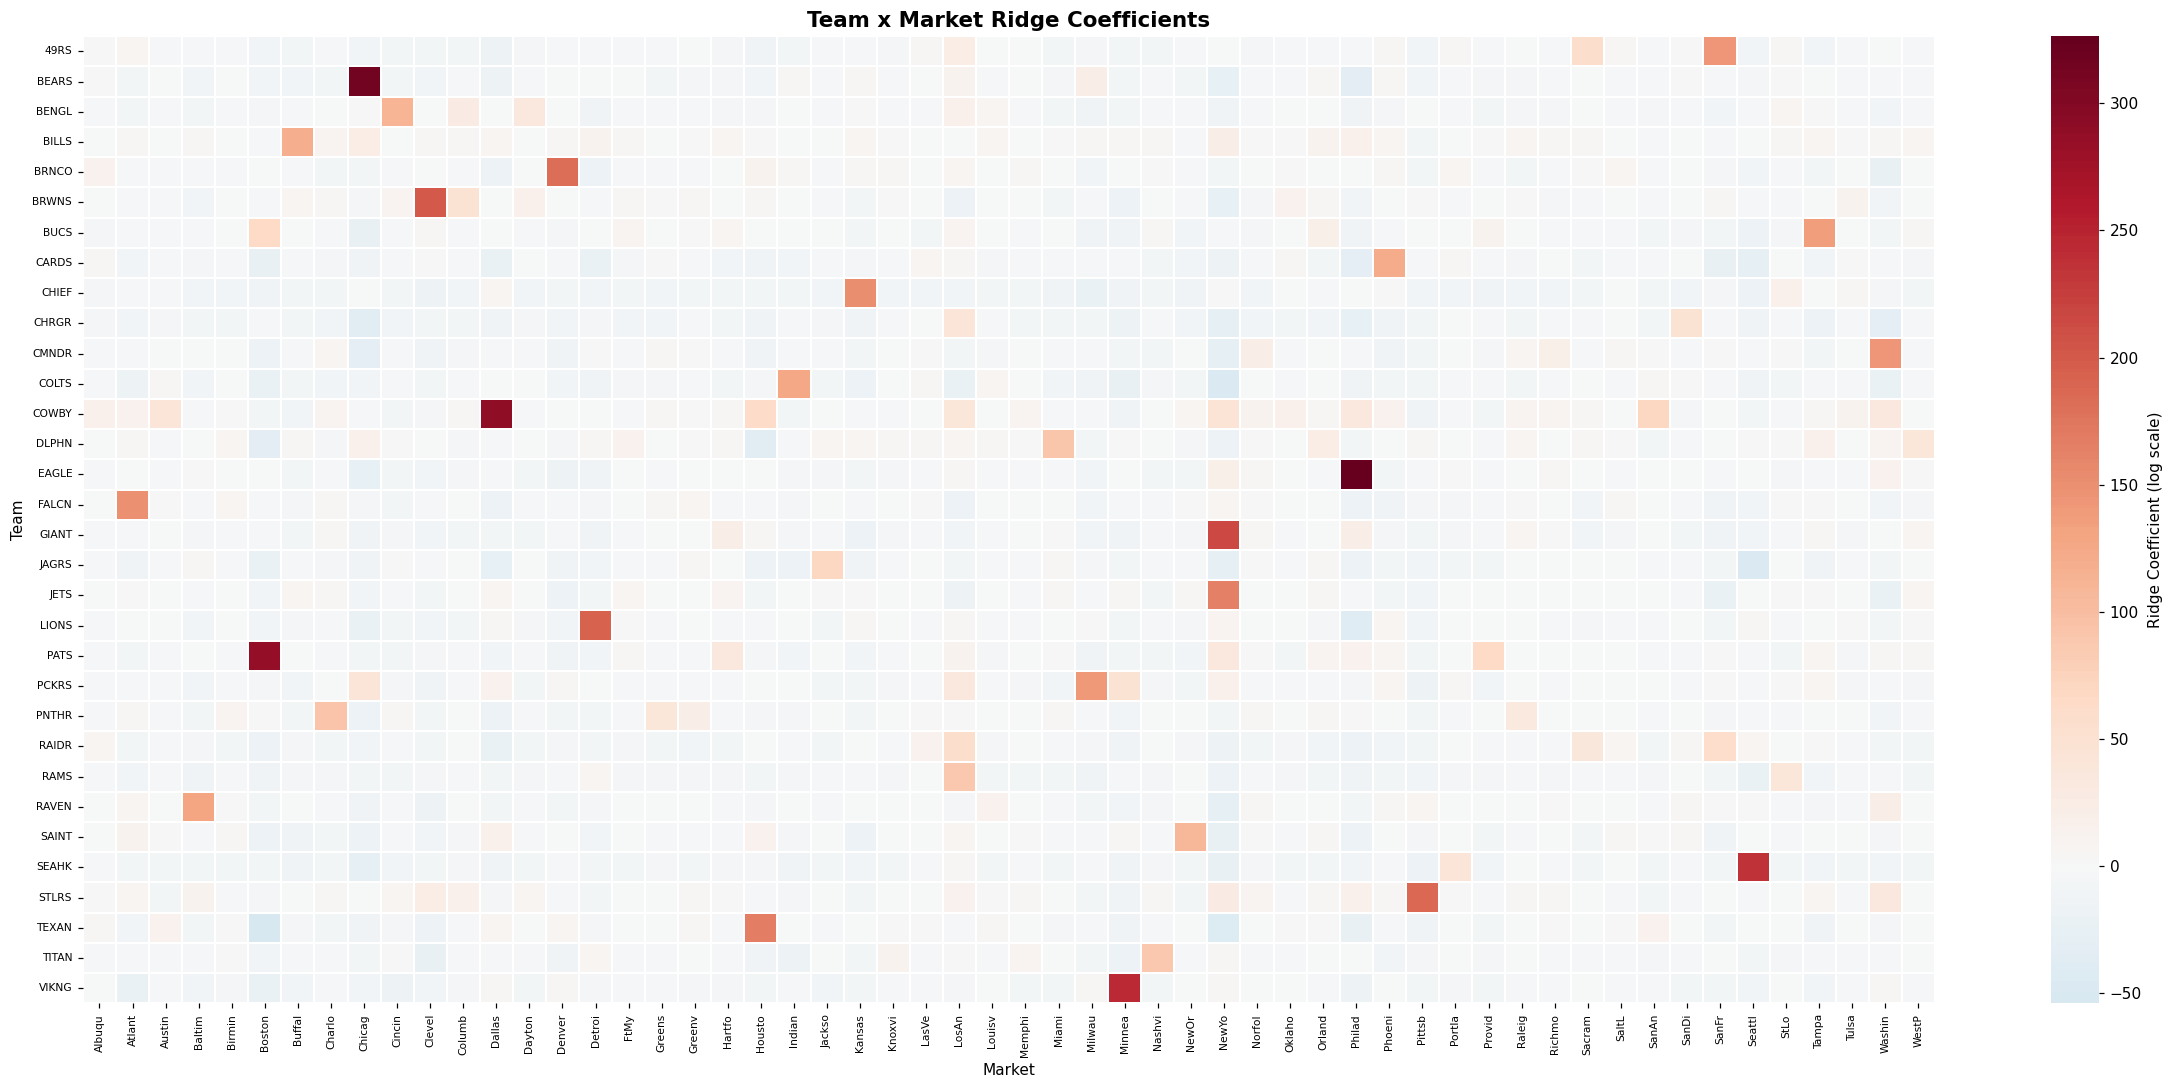

In [40]:
fig, ax = plt.subplots(figsize=(22, 10))
sns.heatmap(coef_df, cmap='RdBu_r', center=0, linewidths=0.3, linecolor='white', ax=ax,
            cbar_kws={'label': 'Ridge Coefficient (log scale)'})
ax.set_title('Team x Market Ridge Coefficients', fontsize=14, fontweight='bold')
ax.set_xlabel('Market')
ax.set_ylabel('Team')
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=7)
plt.tight_layout()
plt.show()

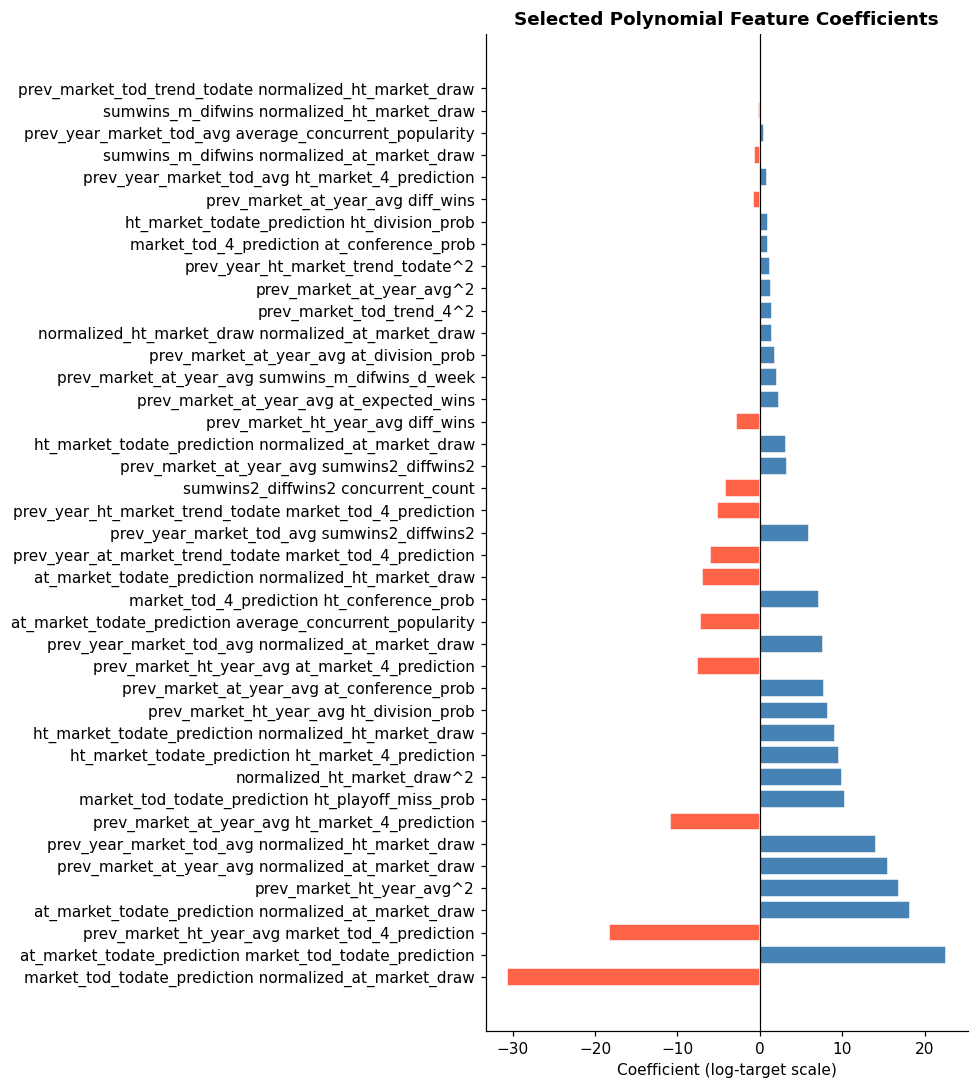

In [41]:
num_coef_rows = []
for feat in ordered_features_curated:
    if feat in final_features:
        num_coef_rows.append({'feature': feat, 'coef': coefs[final_features.index(feat)]})

num_coef_df = pd.DataFrame(num_coef_rows).sort_values('coef', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 10))
colors = ['steelblue' if c > 0 else 'tomato' for c in num_coef_df['coef']]
ax.barh(num_coef_df['feature'], num_coef_df['coef'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-target scale)')
ax.set_title('Selected Polynomial Feature Coefficients', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 12 Baseline Comparison

| Model | OOF / Val R2 | Notes |
|---|---|---|
| **Ridge Regression** | **91.3%** | Polynomial Lasso selection + OHE market/team interactions |
| LightGBM + Optuna | ~91.5% | Native categoricals, 500 Optuna trials, log1p target |
| OHE MLP | ~91.2% | 2,021-dim input, [2021->1024->256->64->1], pure NumPy |
| Embedding MLP | ~90.9% | 227-dim after embedding, pure NumPy |

Machine Learning literature has suggested that tree-based models are best suited for tabular data of mixed datatypes. This emperical analysis supports that claim. However there are at least **two big takeaways** from my perspective: 

 **1)** The Linear model holds its own against gradient boosted trees and neural networks on this dataset - almost claiming the top spot over LightGBM. Often viewed to be inferior, a linear model with thoughfully engineered features cast into polynomial feature space, properly regularized and cross-validated, can capture just about the same signal as highly non-linear models can. Of course this result also depends on the data. In this case, you can make a strong argument that TV ratings are foundationally an additive environment; they can be broken down into a sum of their parts: away team, home team, market, network, time of day, and relevant numerical features. So it makes sense that a linear model would be competitive here. It also has the benefit of being arguably the most interperetable model - and it is far-and-away the simplest model (the fewest parameters at ~ 2000).

 **2)** The MLP w/ embeddings model also performs quite well despite having about 2 million less parameters than its OHE MLP counterpart (only gives up 0.3% R squared for that compression). This delta could likely be closed with further tuning of drop-out hyperparameters or network width and depth. This is a good lesson: the overhead of wide or deep neural networks on tabular data is likely not worth it - lots of redundant or unused or under-utilized parameters. By converting sparse categorrical columns to dense embeddings, we not only decrease the number of parameters needed by our model, but we also gain model interperetability. In addition to being able to recover the highly practical team x market coefficient matrix, we can also utilize the embedding vectors of each team, market, and network to inspect cosine similarity matricies, 2D PCA clusterings, and embedding norms that tell us not only relative importance of our categorical features, but also where these features overlap or bring similar or divergent signal to the model. These are learnings we can't get from Linear, OHE MLP, or tree-based methodologies. 

 If I were to continue on with this project or seek to deploy a production model, I would drop the OHE MLP framework and continue to put training resources into LightGBM, OHE w/ embeddings, and the Linear Model to eventually pick the winning model. We also seem to be nearing the peak of how much signal can be extracted from the current dataset, given that all 3 frameworks are converging to the same answer. Therefore aquiring new data sources, such as jersey sales by market, or social media following demographic reports, would likely be a worthwhile endeavor. Like any real environment, not all the variance can be explained, especially true in this case where we are intentionally only using pre-season data so that the models can be used in schedule-optimization workflows downstream. 